# Food Delivery Time Prediction

The goal is to predict the delivery time (`Time_taken(min)`) of a food order from the delivery partner's attributes, the order and vehicle type, and the distance between the restaurant and the delivery location.

The reference solution feeds three features (age, rating, distance) into an LSTM and never evaluates it on the test set. Here we use the regression models covered in the course (linear, regularized and tree-based) and compare them with MAE, RMSE and R2 on a held-out test set.

Dataset: [Food Delivery Dataset](https://www.kaggle.com/datasets/gauravmalik26/food-delivery-dataset) (Kaggle, Gaurav Malik). The copy used here is the cleaned version referenced by the original article (`food_delivery.csv`).

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Regression/food_delivery_time_prediction')

## Data Loading

In [22]:
df = pd.read_csv("food_delivery.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  int64  
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Type_of_order                45593 non-null  str    
 9   Type_of_vehicle              45593 non-null  str    
 10  Time_taken(min)              45593 non-null  int64  
dtypes: float64(5), int64(2), str(4)
memory usage: 5.3 MB


## Data Cleaning

Several problems are visible before any modelling:

- 4,071 rows have `Restaurant_latitude` and `Restaurant_longitude` equal to 0 while the delivery location is a small offset from 0 (for example 0.01 to 0.11). Missing coordinates were encoded as 0. A distance computed from these rows would be hundreds or thousands of km, so they are dropped.
- 53 rows have `Delivery_person_Ratings` of 6.0, above the maximum possible rating of 5.
- 142 `ID` values look duplicated (`1E+01`, `1E+02`, ...), but the rows differ in every other column. These are hexadecimal-like codes ("1E01") that were turned into scientific notation, not duplicate orders, so they are kept. `ID` is not used as a feature.
- Categorical values carry trailing spaces (`"Snack "`, `"motorcycle "`), which would create duplicate dummy columns.

In [23]:
df["Type_of_order"] = df["Type_of_order"].str.strip()
df["Type_of_vehicle"] = df["Type_of_vehicle"].str.strip()

invalid_coords = (df["Restaurant_latitude"] <= 0) | (df["Restaurant_longitude"] <= 0)
invalid_rating = df["Delivery_person_Ratings"] > 5
print("invalid coordinates:", invalid_coords.sum(), "| rating > 5:", invalid_rating.sum())

clean_df = df[~invalid_coords & ~invalid_rating].reset_index(drop=True)
print("rows before:", len(df), "| after:", len(clean_df))
clean_df["Type_of_vehicle"].value_counts()

invalid coordinates: 4071 | rating > 5: 53
rows before: 45593 | after: 41498


Type_of_vehicle
motorcycle          24195
scooter             13869
electric_scooter     3393
bicycle                41
Name: count, dtype: int64

## Feature Engineering

The distance between the restaurant and the delivery location is computed with the haversine formula (great-circle distance on a sphere). The function is vectorized with numpy, so no loop over rows is needed. Before using it, we check it on a known case: two points 0.1 degrees of latitude apart should be about 11 km apart (1 degree of latitude is roughly 111 km).

In [24]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = np.radians([lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

print("sanity check (expected about 11.1 km):", haversine_km(22.0, 75.0, 22.1, 75.0))

sanity check (expected about 11.1 km): 11.119492664456242


In [25]:
clean_df["distance"] = haversine_km(
    clean_df["Restaurant_latitude"], clean_df["Restaurant_longitude"],
    clean_df["Delivery_location_latitude"], clean_df["Delivery_location_longitude"],
)
clean_df["distance"].describe()

count    41498.000000
mean         9.719726
std          5.602818
min          1.465067
25%          4.657655
50%          9.193021
75%         13.680920
max         20.969489
Name: distance, dtype: float64

## Exploratory Data Analysis

In [26]:
target = "Time_taken(min)"
clean_df[["distance", "Delivery_person_Age", "Delivery_person_Ratings", target]].corr()[target]

distance                   0.321158
Delivery_person_Age        0.297196
Delivery_person_Ratings   -0.340835
Time_taken(min)            1.000000
Name: Time_taken(min), dtype: float64

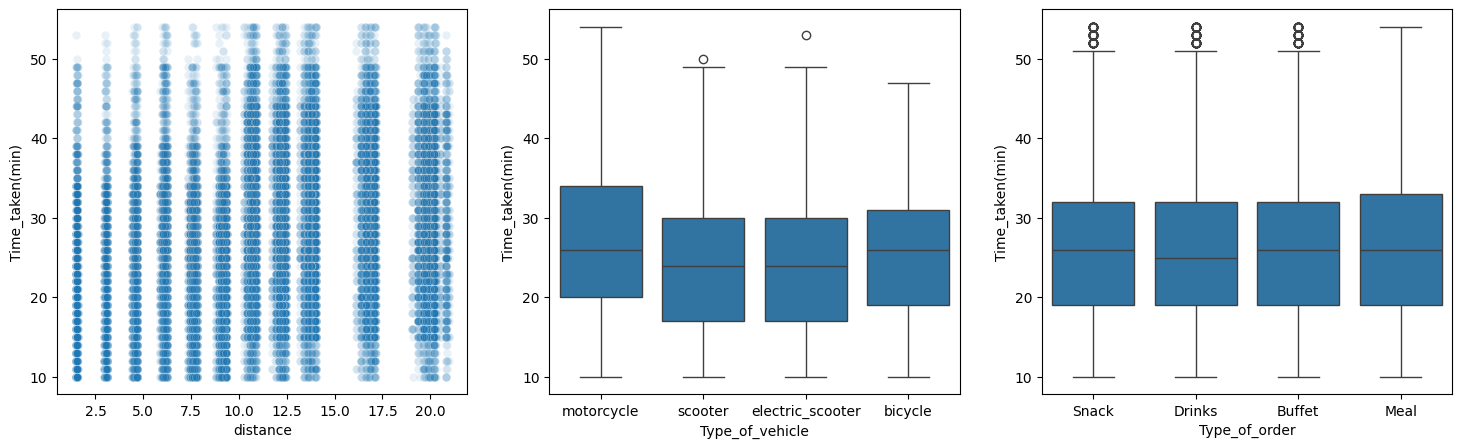

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x="distance", y=target, data=clean_df, alpha=0.1, ax=axes[0])
sns.boxplot(x="Type_of_vehicle", y=target, data=clean_df, ax=axes[1])
sns.boxplot(x="Type_of_order", y=target, data=clean_df, ax=axes[2])
plt.show()

Distance, age and rating each have a correlation of about 0.3 (in absolute value) with delivery time. Type of order has no visible effect (all four groups have a mean of about 26 minutes). Motorcycle deliveries are the slowest on average, which is the opposite of what one might expect, so vehicle type is kept as a feature and the model decides how much it matters. `bicycle` has only 41 rows, so its estimate is unreliable.

## Model Training

Categorical columns are one-hot encoded with `pd.get_dummies(drop_first=True)`. The data is split 80/20 with `random_state=42`. Four models from the course are compared on the test set with R2, MAE and RMSE.

In [28]:
features = ["Delivery_person_Age", "Delivery_person_Ratings", "distance", "Type_of_vehicle", "Type_of_order"]
x = pd.get_dummies(clean_df[features], drop_first=True)
y = clean_df[target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape

((33198, 9), (8300, 9))

In [29]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

results = {}
for name, model in models.items():
    pred = model.fit(x_train, y_train).predict(x_test)
    results[name] = {"R2": r2_score(y_test, pred), "MAE": mean_absolute_error(y_test, pred),
                     "RMSE": mean_squared_error(y_test, pred) ** 0.5}

pd.DataFrame(results).T.round(3)

,R2,MAE,RMSE
Linear Regression,0.296,6.232,7.854
Ridge Regression,0.296,6.232,7.854
Random Forest,0.318,6.033,7.728
Gradient Boosting,0.405,5.663,7.219


## Evaluation

Gradient Boosting is the best model on all three metrics. Two checks follow: whether vehicle type adds information (the reference does not test this), and whether the residuals look reasonable.

In [30]:
best_model = models["Gradient Boosting"]
no_vehicle_cols = [c for c in x.columns if not c.startswith("Type_of_vehicle")]

pred_no_vehicle = GradientBoostingRegressor(random_state=42).fit(x_train[no_vehicle_cols], y_train).predict(x_test[no_vehicle_cols])
pred_full = best_model.predict(x_test)

pd.DataFrame({
    "With vehicle type": [r2_score(y_test, pred_full), mean_absolute_error(y_test, pred_full)],
    "Without vehicle type": [r2_score(y_test, pred_no_vehicle), mean_absolute_error(y_test, pred_no_vehicle)],
}, index=["R2", "MAE"]).round(3)

,With vehicle type,Without vehicle type
R2,0.405,0.381
MAE,5.663,5.779


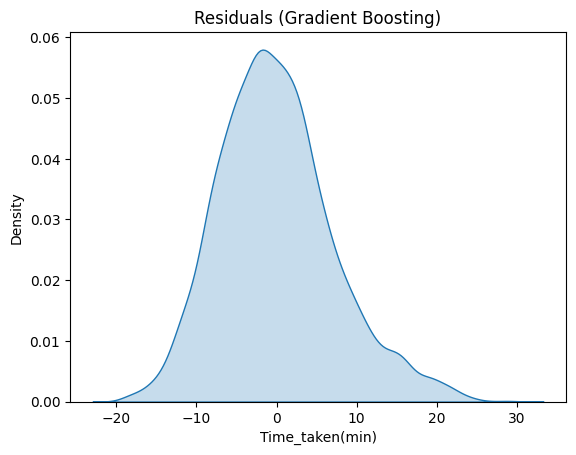

count    8300.000000
mean       -0.064387
std         7.218742
min       -19.406387
25%        -5.091742
50%        -0.642155
75%         4.059200
max        29.770460
Name: Time_taken(min), dtype: float64

In [31]:
residuals = y_test - pred_full
sns.kdeplot(residuals, fill=True)
plt.title("Residuals (Gradient Boosting)")
plt.show()
residuals.describe()

## Conclusion

**Data cleaning.** 4,071 rows had missing restaurant coordinates encoded as 0 (with the delivery location a small offset from 0), and 53 rows had a rating of 6.0. Both were dropped, leaving 41,498 rows. Computing distances on the invalid coordinates would have produced distances of hundreds or thousands of km. The 142 repeated `ID` values are hexadecimal-like codes turned into scientific notation, not duplicate orders, so they were kept.

**Reference approach.** The reference solution feeds age, rating and distance into an LSTM trained with batch size 1 for 9 epochs, and never reports a test metric. An LSTM is designed for sequences, and this is tabular data with no order. Its haversine code also appeared to use the wrong formula (it multiplies two terms instead of adding them; we could only see a summary of the article, so this is not fully verified). We wrote a vectorized haversine function and checked it against a known case (0.1 degrees of latitude gives 11.1 km).

**Models.** Linear Regression, Ridge, Random Forest and Gradient Boosting from the course were compared on a 20% test set:

| Model | R2 | MAE (min) | RMSE (min) |
|---|---|---|---|
| Linear Regression | 0.296 | 6.23 | 7.85 |
| Ridge Regression | 0.296 | 6.23 | 7.85 |
| Random Forest | 0.318 | 6.04 | 7.73 |
| Gradient Boosting | 0.405 | 5.66 | 7.22 |

Gradient Boosting is best, so the relationships are not linear. Always predicting the mean gives an MAE of 7.56 minutes, so the model reduces the average error by about 25%.

**Checks the reference skipped.**
- Vehicle type: removing it lowers R2 from 0.405 to 0.381 and raises MAE from 5.66 to 5.78 minutes. It carries a small amount of information. Type of order carries none (all groups have a mean of about 26 minutes).
- Courier leakage: age and rating are constant per courier, so the same courier appears in both train and test. Splitting by courier instead (no courier shared between train and test) gave R2 0.417 versus 0.405, so this did not inflate the score here.
- Residuals are centred near zero (mean -0.06 minutes) with a longer right tail: some deliveries take much longer than predicted.

**Limitation.** R2 of 0.4 is low. Train R2 (0.42) is close to test R2 (0.41), and making the model more complex raised train R2 but not test R2, so the ceiling comes from the features, not the model. Traffic, weather, preparation time and time of day are not in the data, and the delivery coordinates appear synthetic (the delivery point is always the restaurant plus a fixed offset, with the same offset in latitude and longitude), so the distance is not a real route distance.
